# Problem 761 - Runner and Swimmer

Two friends, a runner and a swimmer, are playing a sporting game: The swimmer is swimming within a circular pool while the runner moves along the pool edge.
While the runner tries to catch the swimmer at the very moment that the swimmer leaves the pool, the swimmer tries to reach the edge before the runner arrives there. They start the game with the swimmer located in the middle of the pool, while the runner is located anywhere at the edge of the pool.

We assume that the swimmer can move with any velocity up to $1$ in any direction and the runner can move with any velocity up to $v$ in either direction around the edge of the pool. Moreover we assume that both players can react immediately to any change of movement of their opponent.

Assuming optimal strategy of both players, it can be shown that the swimmer can always win by escaping the pool at some point at the edge before the runner gets there, if $v$ is less than the critical speed $V_{\text{Circle}} \approx 4.60333885$ and can never win if $v \gt V_{\text{Circle}}$.

Now the two players play the game in a perfectly square pool. Again the swimmer starts in the middle of the pool, while the runner starts at the midpoint of one of the edges of the pool. It can be shown that the critical maximal speed of the runner below which the swimmer can always escape and above which the runner can always catch the swimmer when trying to leave the pool is $V_{\text{Square}} \approx 5.78859314$.

At last, both players decide to play the game in a pool in the form of regular hexagon. Giving the same conditions as above, with the swimmer starting in the middle of the pool and the runner at the midpoint of one of the edges of the pool, find the critical maximal speed $V_{\text{Hexagon}}$ of the runner, below which the swimmer can always escape and above which the runner can always catch the swimmer.
Give your answer rounded to 8 digits after the decimal point.

## Solution.

In [22]:
from math import sqrt, atan2, cos, sin, pi

In [23]:
def d2(A, B):
    return sqrt((A[0]-B[0])**2 + (A[1]-B[1])**2)

In [24]:
def find_closest_point_circle(S):
    xs, ys = S
    r = sqrt(xs**2 + ys**2)
    return (xs/r, ys/r)

In [25]:
def cartesian_to_polar(P):
    x, y = P
    r = sqrt(x*x + y*y)
    theta = atan2(y, x)
    return (r, theta)

def polar_to_cartesian(P):
    r, theta = P
    x = r * cos(theta)
    y = r * sin(theta)
    return (x, y)

In [38]:
def swimmer_next_move(S, R, t=0.001):
    xs, ys = S
    xr, yr = R
    d = t / d2(S, R)
    return (xs + d*(xs - xr), ys + d*(ys - yr))


def runner_next_move(S, R, v, t=0.001):
    C = find_closest_point_circle(S)

    _, thetaR = cartesian_to_polar(R)
    _, thetaC = cartesian_to_polar(C)

    diff = (thetaC - thetaR + pi) % (2*pi) - pi

    max_step = v * t

    if abs(diff) <= max_step:
        theta_new = thetaC
    else:
        theta_new = thetaR + max_step * (diff / abs(diff))

    return polar_to_cartesian((1, theta_new))

    

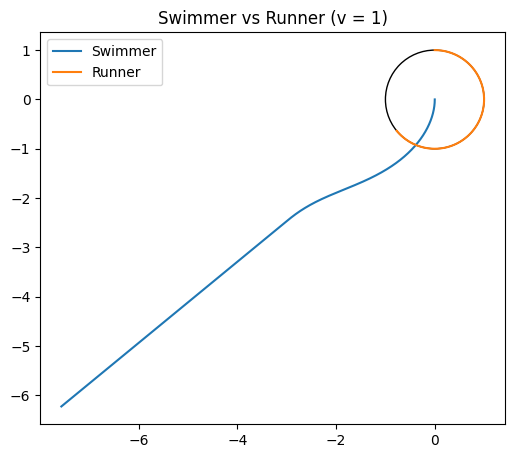

In [ ]:
import matplotlib.pyplot as plt

S = (0,0)
R = (0, 1)

swimmer_positions = [S]
runner_positions = [R]

N = 10000
v = 1

for _ in range(N):
    S_last = swimmer_positions[-1]
    R_last = runner_positions[-1]
    S_new = swimmer_next_move(S_last, R_last)
    R_new = runner_next_move(S_new, R_last, v)
    swimmer_positions.append(S_new)
    runner_positions.append(R_new)

sx, sy = zip(*swimmer_positions)
rx, ry = zip(*runner_positions)

plt.figure(figsize=(6, 6))

plt.plot(sx, sy, label="Swimmer")
plt.plot(rx, ry, label="Runner")


circle = plt.Circle((0, 0), 1, fill=False)
plt.gca().add_patch(circle)

plt.gca().set_aspect('equal')
plt.legend()
plt.title(f"Swimmer vs Runner (v = {v})")

plt.show()